In [ ]:
import pandas as pd
df = pd.read_csv("mxmh_survey_results.csv")
df_numeric = df[["Age","Hours per day", "BPM","Anxiety","Depression","Insomnia","OCD"]]


In [14]:
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [34]:
import statsmodels.api as sm
df[df_numeric.columns] = df_numeric.fillna(df_numeric.mean())

# Предположим, что 'OCD' — целевая переменная
# а ['Fav genre', 'Hours per day', 'Age'] — независимые факторы

X = df[['Fav genre', 'Hours per day', 'Age']] 
X = pd.get_dummies(X, columns=['Fav genre'], drop_first=True)
X = X.dropna() 
X = X.astype({col: 'float64' for col in X.columns if X[col].dtype == 'bool'})
Y = df['OCD']
# Добавляем константу в матрицу признаков
X = sm.add_constant(X)
# Строим модель
model_sm = sm.OLS(Y, X).fit()
print(model_sm.summary())

model_sk = LinearRegression()
model_sk.fit(X, Y)
# Коэффициенты
print("Intercept:", model_sk.intercept_)
print("Coefficients:", model_sk.coef_)
# Предсказание
y_pred = model_sk.predict(X)

r2 = r2_score(Y, y_pred)
mse = mean_squared_error(Y, y_pred)
print("R^2:", r2)
print("MSE:", mse)
#Метрики ужасные, тк там нет зависимостей в таком виде, надо использовать другого рода модели
#Тот же лес дает r2=0.64
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, Y)
print("RF R^2:", rf.score(X, Y))

                            OLS Regression Results                            
Dep. Variable:                    OCD   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.680
Date:                Wed, 09 Apr 2025   Prob (F-statistic):             0.0416
Time:                        11:28:59   Log-Likelihood:                -1798.2
No. Observations:                 736   AIC:                             3632.
Df Residuals:                     718   BIC:                             3715.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

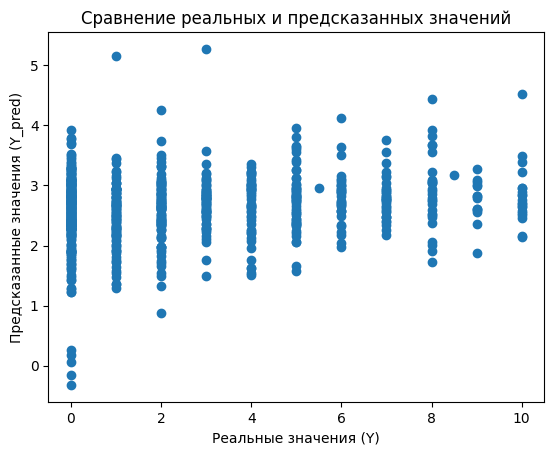

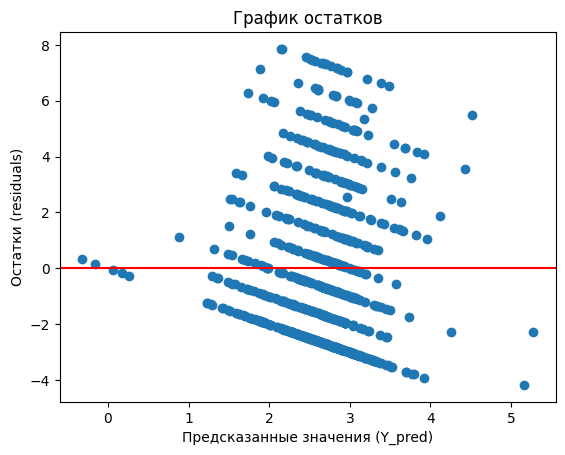

In [25]:
plt.scatter(Y, y_pred)
plt.xlabel("Реальные значения (Y)")
plt.ylabel("Предсказанные значения (Y_pred)")
plt.title("Сравнение реальных и предсказанных значений")
plt.show()

residuals = Y - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Предсказанные значения (Y_pred)")
plt.ylabel("Остатки (residuals)")
plt.title("График остатков")
plt.axhline(y=0, color='red')
plt.show()